<h1 style="color: red;">7.1</h1>

In [1]:
import numpy as np
from numpy import linalg as la
A = np.array([[1,2,3],[0,-4,1],[0,3,-1]]).reshape(3,3)
print(A)
determinant = la.det(A)
print('determinant:', determinant)

b = np.array([2,2,1])
Ainv = la.inv(A)
xyz = Ainv@b
print('The answer for x,y,z is:', xyz)


from numpy.linalg import inv
A = A/3
print(f"Matrix A:\n{A}")
print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}\n")
''' Not needed since the previous is already not equal to the identity matrix
print(f"\nInverse of A:\n{inv(A)}")
print(f"\nis equal to the transpose:\n{A.T}")
print(f"\nAlternative check with function array_equal(): {np.array_equal(A.T, inv(A))}")
print(f"\nAlternative check with function allclose(): {np.allclose(A.T, inv(A))}")
'''

eigval, eigvec = la.eig(A)
print("Eigenvalues = ", eigval)
print(f"\nNormalized eigenvectors:\n{eigvec}")

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
determinant: 1.0
The answer for x,y,z is: [ 38.  -3. -10.]
Matrix A:
[[ 0.33333333  0.66666667  1.        ]
 [ 0.         -1.33333333  0.33333333]
 [ 0.          1.         -0.33333333]]

A.AT should be the identity matrix:
[[ 1.55555556 -0.55555556  0.33333333]
 [-0.55555556  1.88888889 -1.44444444]
 [ 0.33333333 -1.44444444  1.11111111]]
[[False False False]
 [False False False]
 [False False False]]

Eigenvalues =  [ 0.33333333 -1.59709595 -0.06957072]

Normalized eigenvectors:
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


<h1 style="color: black;">7.2</h1>

<h1 style="color: red;">7.3</h1>

In [2]:
from math import cos, sin, radians

def Ex(a):
    a = radians(a)
    Ex = np.array([[1,0,0],[0,cos(a),sin(a)],[0,-sin(a),cos(a)]]).reshape(3,3)
    return Ex
def Ey(b):
    b = radians(b)
    Ey = np.array([[cos(b),0,-sin(b)],[0,1,0],[sin(b),0,cos(b)]]).reshape(3,3)
    return Ey
def Ez(c):
    c = radians(c)
    Ez = np.array([[cos(c),sin(c),0],[-sin(c),cos(c),0],[0,0,1]]).reshape(3,3)
    return Ez


E = Ez(180-123)@Ey(90-27.4)@Ez(192.25)
print(E)

if np.allclose(E.T, inv(E)):
    print('Yep, ET = Einv')
    
    if la.det(E) == 1:
        print('yep, detE = 1')
        print('E is a rotation matrix')
    else:
        print('nope, det E /=1')
        print('E is not a rotation matrix')
else:
    print('nope, ET /= Einv')
    
    if la.det(E) == 1:
        print('yep, detE = 1')
    else:
        print('nope, det E /=1')
        
    print('E is a rotation matrix')

eigval, eigvec = la.eig(E)
print("Eigenvalues = ", eigval,'\n')


d = radians(27.4)
a = radians(192.25)
L = np.array([cos(d)*cos(a),cos(d)*sin(a), sin(d)])
print(L)
print('norm:', la.norm(L))

rot = E@L
print(rot)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
Yep, ET = Einv
yep, detE = 1
E is a rotation matrix
Eigenvalues =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ] 

[-0.86760081 -0.1883746   0.46019978]
norm: 1.0
[2.77555756e-17 5.55111512e-17 1.00000000e+00]


<h1 style="color: black;">7.4</h1>

In [3]:
import numpy as np
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

def Y(X):
    for i in range(len(x)-1):
        if x[i] <= X <= x[i+1]:
            x1 = x[i]
            x2 = x[i+1]
            y1 = y[i]
            y2 = y[i+1]
            ans = y1 + ( ((y2-y1)*(X-x1)) / (x2-x1) )
            return ans
            
print(Y(2.5))    
np.interp(2.5,x,y)
            

0.5909090909090908


np.float64(0.5909090909090908)

<h1 style="color: red;">7.5</h1>

[ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331360e+01  2.91867715e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


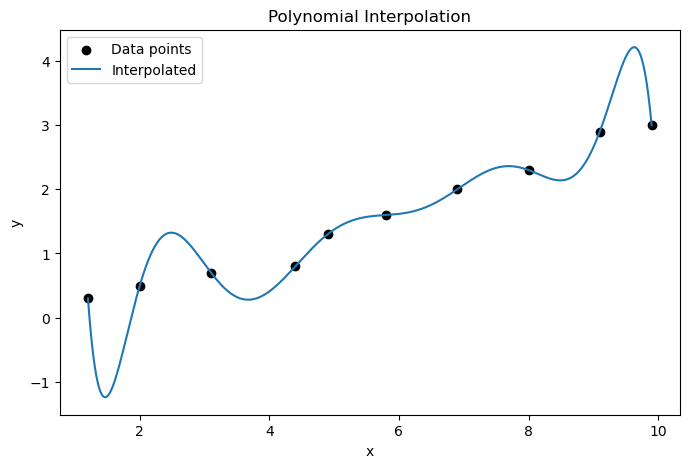

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

#Make matrix n by n where n is the length of x (and y)
N = len(x)
A = np.zeros((N, N))

# Replace the zeros in matrix A with the values of x
for i in range(N):
    for j in range(N):
        A[i, j] = x[i]**j

# Solve for coefficients
a = np.linalg.solve(A, y)
print(a)

#make x and y valeus for the plot
x_plot = np.linspace(min(x), max(x), 500)
y_plot = np.zeros_like(x_plot)

# replace the values in y (previously 0) to a polynomial equation
for i in range(N):
    y_plot += a[i] * x_plot**i

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='black', label='Data points')
plt.plot(x_plot, y_plot, label='Interpolated')

#labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Interpolation')

plt.legend()
plt.show()

<h1 style="color: red;">7.6</h1>

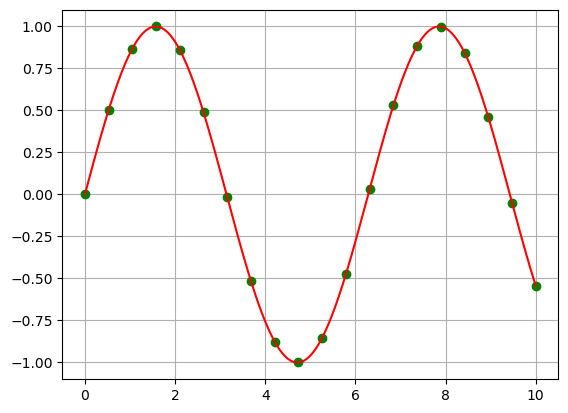

In [24]:

import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.linspace(0,10,20)
y = np.sin(x)
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(0,10,250)  # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()


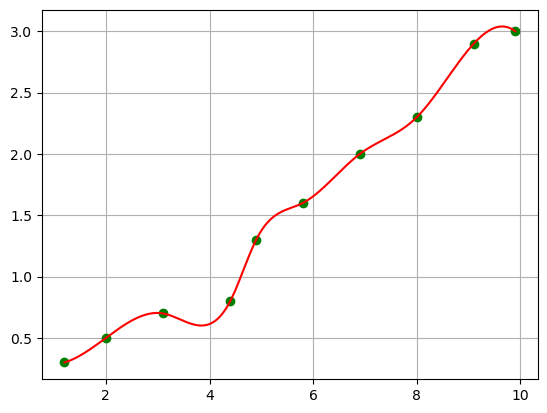

In [36]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(x[0],x[-1],250)  # notice outside the original domain
newy = f(newx)


fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

# When comparing it doesnt have the wierd wobbles at the start and end that the one in 7.5 has

In [49]:
import numpy as np
from scipy.interpolate import interp1d

class Interpolation:
    def __init__(self, x, y):
        self.x = np.array(x)
        self.y = np.array(y)

    # 1. Linear interpolation
    def linear(self, x_val):
        return np.interp(x_val, self.x, self.y)

    # 2. Polynomial interpolation
    def polynomial(self):
        #Make matrix n by n where n is the length of x (and y)
        N = len(self.x)
        A = np.zeros((N, N))

        # Replace the zeros in matrix A with the values of x
        for i in range(N):
            for j in range(N):
                A[i, j] = self.x[i]**j

        # Solve for coefficients
        a = np.linalg.solve(A, self.y)
        return a

    def polynomial_eval(self, x_val):
        coeffs = self.polynomial()
        n = len(coeffs)
        y_val = 0

        for i in range(n):
            y_val += coeffs[i] * (x_val ** (n - i - 1))

        return y_val

    # 3. Cubic spline interpolation
    def spline(self):
        return interp1d(self.x, self.y, kind='cubic')

    # General evaluation function, selects based on input given by user
    def interpolate(self, x_val, method="linear"):
        if method == "linear":
            return self.linear(x_val)

        elif method == "polynomial":
            return self.polynomial_eval(x_val)

        elif method == "spline":
            spline_func = self.spline()
            return spline_func(x_val)

        else:
            raise ValueError("Method must be 'linear', 'polynomial', or 'spline'")

# Create object
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
interp = Interpolation(x, y)

# User input
typee = input('Type 1 for linear, 2 for polynomial and 3 for spline:')
x_val = float(input("Enter x value for which you want the interpolation (x within range): "))


# Calculate and print the corresponding version
if typee == '1':
    y_linear = interp.interpolate(x_val, "linear")
    print(f"Linear interpolation Y: {y_linear}")
elif typee == '2':
    y_poly = interp.interpolate(x_val, "polynomial")
    print(f"Polynomial interpolation Y: {y_poly}")
elif typee == '3':
    print(f"Spline interpolation Y: {y_spline}")
else:
    y_spline = interp.interpolate(x_val, "spline")
    print('please give a valid number: 1, 2 or 3')

Type 1 for linear, 2 for polynomial and 3 for spline: 2
Enter x value for which you want the interpolation (x within range):  4.3


Polynomial interpolation Y: 58999169.79193439


<h1 style="color: red;">7.7</h1>

In [38]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


<h1 style="color: blue;">7.8</h1>

<h1 style="color: black;">7.9</h1>

<h1 style="color: red;">7.10</h1>

Intercept and slope are the parameters 
parameters of least squares: [69.93805979 64.13233494] 
parameters of curve fit : [ 9.18949276 71.38296246]


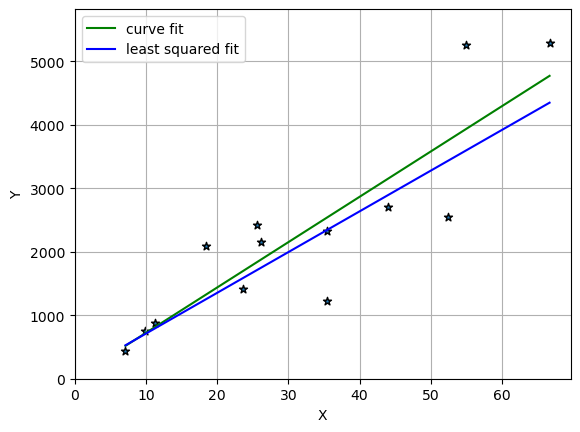

In [75]:
import numpy as np

data = [
    18.49, 2094.75, 0.3, 100,
    35.48, 2320.87, 2.2, 120,
    35.48, 1224.9,  3.0, 80,
    11.34, 872.13,  1.2, 80,
    7.12,  432.2,   0.4, 70,
    9.82,  751,     0.3, 75,
    23.66, 1410,    2.3, 70,
    44,    2700,    4.0, 110,
    66.7,  5292,    5.3, 120,
    52.4,  2550,    5.2, 100,
    55,    5253,    6.1, 150,
    25.6,  2419,    3.2, 110,
    26.19, 2158,    2.8, 110
]

# define columns correctly and errors too
data = np.asarray(data)

x = data[0::4]
y = data[1::4]
sigx = data[2::4]
sigy = data[3::4]


''' LEAST SQUARES FITTING'''

from scipy.optimize import leastsq

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = [0, 70.0]

data_tuple = (x, y, sigy)   # define the args for the result

result = leastsq(residuals, beta_start, args=data_tuple, full_output=1)

(beta, pcov, infodict, errmsg, ier) = result # define each item from the result as a diff thing

# Convert unscaled standard errors to scaled standard errors
if not pcov is None:
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())
    dof = len(fvec) - len(beta)
    sderr = perror * np.sqrt(chi2/dof)
'''
print("====== LEASTSQ RESULTS ==========")
print("Params:                         ", beta)
print("Unscaled standard error(s):     ", perror)
print("Scaled standard error(s):       ", sderr)
print("Degrees of freedom:             ", dof)
print("Chi^2 min:                      ", chi2)
print("Reduced Chi squared:            ", chi2/dof)
print("Iterations:                     ", "Not returned by leastsq()")
print("Number of function evaluations: ", infodict['nfev'])
'''
beta_lsqwei = beta


''' CURVE_FIT'''

from matplotlib.pyplot import subplots, show
from scipy.optimize import curve_fit

def model_cf(x, beta0, beta1):
    return beta0 + beta1*x

# Do the fitting
beta, pcov = curve_fit(model_cf, x, y)

# Calculate end points for the best straight line
X = np.array([x.min(), x.max()])
Y = model_cf(X, beta[0], beta[1])

beta_curve_fit = beta   # FIX: store parameters, not [X,Y]

''' FINAL VALUES'''

print('Intercept and slope are the parameters', '\nparameters of least squares:', beta_lsqwei,
      '\nparameters of curve fit :', beta_curve_fit)


'''PLOTTING'''

from matplotlib.pyplot import figure, show

xmin = np.min(x)
xmax = np.max(x)

fig = figure()
frame = fig.add_subplot(1,1,1)

frame.scatter(x, y, marker='*', ec='k')

# curve fit
frame.plot(X, Y, label="curve fit", color='green')

# Least squares fit
ymin = model(beta_lsqwei, xmin)
ymax = model(beta_lsqwei, xmax)

frame.plot([xmin, xmax], [ymin, ymax], label="least squared fit", color='blue')


frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*y.max())
frame.grid()
frame.legend()

show()

<h1 style="color: blue;">7.11</h1>

<h1 style="color: black;">7.12</h1>

<h1 style="color: blue;">7.13</h1>

<h1 style="color: red;">7.14</h1>